In [1]:
import sys
import nibabel as nib
import nilearn
import numpy as np
import pandas as pd

print("Python executable:")
print(sys.executable)

print("\nNibabel version:", nib.__version__)
print("Nilearn version:", nilearn.__version__)

print("\nEnvironment working.")

Python executable:
/home/john-walkey/miniforge3/envs/neuro/bin/python

Nibabel version: 5.4.0
Nilearn version: 0.13.1

Environment working.


In [2]:
from nilearn import datasets

development_dataset = datasets.fetch_development_fmri(
    n_subjects=1
)

print(development_dataset)

[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
{'func': ['/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'], 'confounds': ['/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv'], 'phenotypic':     participant_id    Age AgeGroup Child_Adult Gender Handedness
122   sub-pixar123  27.06    Adult       adult      F          R, 'description': ".. _development_dataset:\n\ndevelopment fMRI dataset\n========================\n\nAccess\n------\nSee :func:`nilearn.datasets.fetch_development_fmri`.\n\nNotes\n-----\nThis movie-watching based functional MRI dataset is used for teaching

In [3]:
print("\nFunctional image:")
print(development_dataset.func[0])

print("\nConfounds file:")
print(development_dataset.confounds[0])

print("\nPhenotypic information:")
print(development_dataset.phenotypic)


Functional image:
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz

Confounds file:
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv

Phenotypic information:
    participant_id    Age AgeGroup Child_Adult Gender Handedness
122   sub-pixar123  27.06    Adult       adult      F          R


In [4]:
fmri_img = nib.load(development_dataset.func[0])

print(fmri_img)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (50, 59, 50, 168)
affine:
[[   4.    0.    0.  -96.]
 [   0.    4.    0. -132.]
 [   0.    0.    4.  -78.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  4  50  59  50 168   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 4. 4. 4. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : align

In [5]:
print("Image shape:")
print(fmri_img.shape)

Image shape:
(50, 59, 50, 168)


In [6]:
fmri_data = fmri_img.get_fdata()

print("Data type:", type(fmri_data))
print("Array shape:", fmri_data.shape)

Data type: <class 'numpy.ndarray'>
Array shape: (50, 59, 50, 168)


In [7]:
voxel_timeseries = fmri_data[25, 30, 25, :]

print("Voxel time series shape:")
print(voxel_timeseries.shape)

print("\nFirst 10 values:")
print(voxel_timeseries[:10])

Voxel time series shape:
(168,)

First 10 values:
[467.43528891 455.8810544  461.65817165 455.8810544  450.10393715
 455.8810544  455.8810544  455.8810544  467.43528891 455.8810544 ]


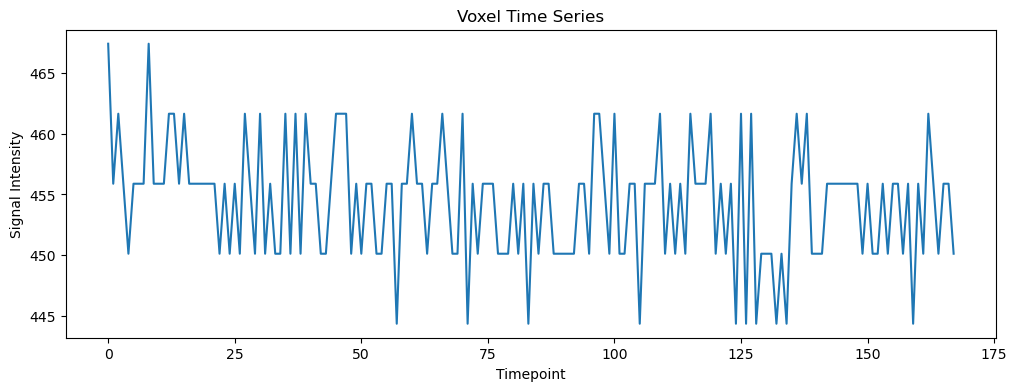

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(voxel_timeseries)

plt.title("Voxel Time Series")
plt.xlabel("Timepoint")
plt.ylabel("Signal Intensity")

plt.show()

In [9]:
voxel_A = fmri_data[25, 30, 25, :]
voxel_B = fmri_data[30, 35, 20, :]

correlation = np.corrcoef(voxel_A, voxel_B)[0, 1]

print("Correlation between voxels:")
print(correlation)

Correlation between voxels:
-0.06914139298058668


In [10]:
voxels = [
    fmri_data[25, 30, 25, :],
    fmri_data[30, 35, 20, :],
    fmri_data[20, 25, 30, :],
    fmri_data[35, 20, 25, :]
]

connectivity_matrix = np.corrcoef(voxels)

print(connectivity_matrix)

[[ 1.         -0.06914139 -0.1647137   0.00470265]
 [-0.06914139  1.          0.19700393  0.06059513]
 [-0.1647137   0.19700393  1.          0.03048321]
 [ 0.00470265  0.06059513  0.03048321  1.        ]]


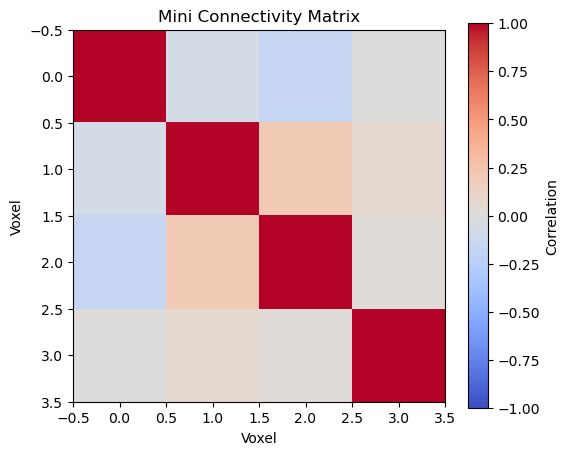

In [11]:
plt.figure(figsize=(6, 5))

plt.imshow(connectivity_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.title("Mini Connectivity Matrix")

plt.xlabel("Voxel")
plt.ylabel("Voxel")

plt.show()